# Simple Visualizer for S2 datasets

In [1]:
import rasterio
import numpy as np
import torch
import matplotlib.pyplot as plt
import pathlib
import shapely
import fiona.transform
from mpl_toolkits.basemap import Basemap
from mpl_toolkits.axes_grid1 import make_axes_locatable

def get_example_image(path, plot=True):
    """
    Loads example Sentinel-2 image from path to tif file
    :param path: Path to image file
    :param plot: If True, will plot an RGB image of the satellite image
    :return: Normalized image as torch tensor
    """
    with rasterio.open(path) as f:
            data = f.read().astype(np.float32)
            image = data / 10000.0
            B10 = np.zeros((1, *image.shape[1:]), dtype=image.dtype)
            image = np.concatenate([image[:10], B10, image[10:]], axis=0)
            image = torch.tensor(image)

            if plot:
                    # Read the first three RGB bands (assuming they are bands 4, 3, and 2)
                    red_band = f.read(4) / 10000.0
                    green_band = f.read(3) / 10000.0
                    blue_band = f.read(2) / 10000.0

                    # Stack the bands to create an RGB image
                    rgb_image = np.stack([red_band, green_band, blue_band], axis=-1)

                    # Plot the RGB image
                    plt.imshow(rgb_image)
                    plt.title("RGB Sentinel-2 Image")
                    plt.axis('off')  # Hide axes
                    plt.show()

    return image

def get_metadata(path):
    """
    Loads metadata from a Sentinel-2 image file
    :param path: Path to image file
    :return: Metadata dictionary
    """
    tags = {}

    with rasterio.open(path) as src:
        geom = shapely.geometry.mapping(shapely.geometry.box(*src.bounds))
        warped_geom = fiona.transform.transform_geom(src.crs, "EPSG:4326", geom)
        shape = shapely.geometry.shape(warped_geom)
        x, y = shape.centroid.xy
        x = x[0]
        y = y[0]
        tags = src.tags()
        filename = pathlib.Path(path).name
        t = src.tags().get("datetime")
        id = src.tags().get("granule_id")

    return id, x, y, t, tags

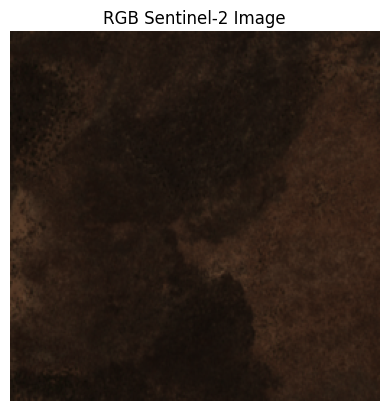

metadata for /mnt/rolf-datastore/home/leca5365/Datasets/satclip-s2-temporal/images/patch_30.tif:
  id: S2B_OPER_MSI_L2A_TL_ESRI_20210309T033455_A020911_T34PDU_N02.12
  x: 20.80957806857924
  y: 11.874097474280509
  t: 2021-03-08T08:57:19.024000+00:00


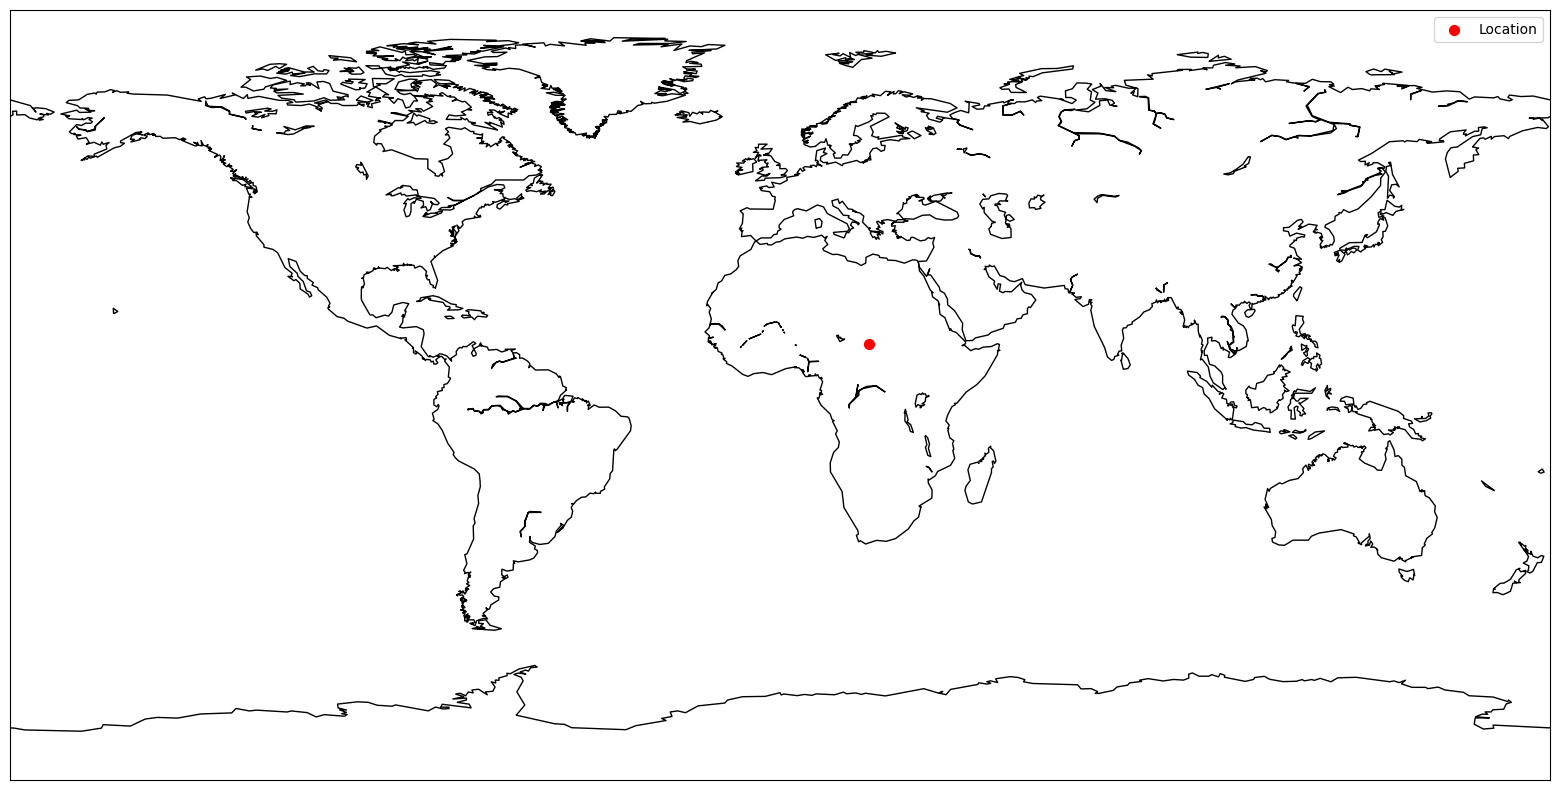

In [38]:
path = "/mnt/rolf-datastore/home/leca5365/Datasets/satclip-s2-temporal/images/patch_30.tif"
# print example image
img = get_example_image(path, plot=True)

# print metadata
id, x, y, t, tags = get_metadata(path)

print(f"metadata for {path}:")
print(f"  id: {id}")
print(f"  x: {x}")
print(f"  y: {y}")
print(f"  t: {t}")
# print(f"  tags: {tags}")

#Plot true and predicted locations
fig, ax = plt.subplots(1,1, figsize=(20, 10))

m = Basemap(projection='cyl', resolution='c', ax=ax)
m.drawcoastlines()
ax.scatter(x, y, s=50, c="red", label="Location")
ax.legend()

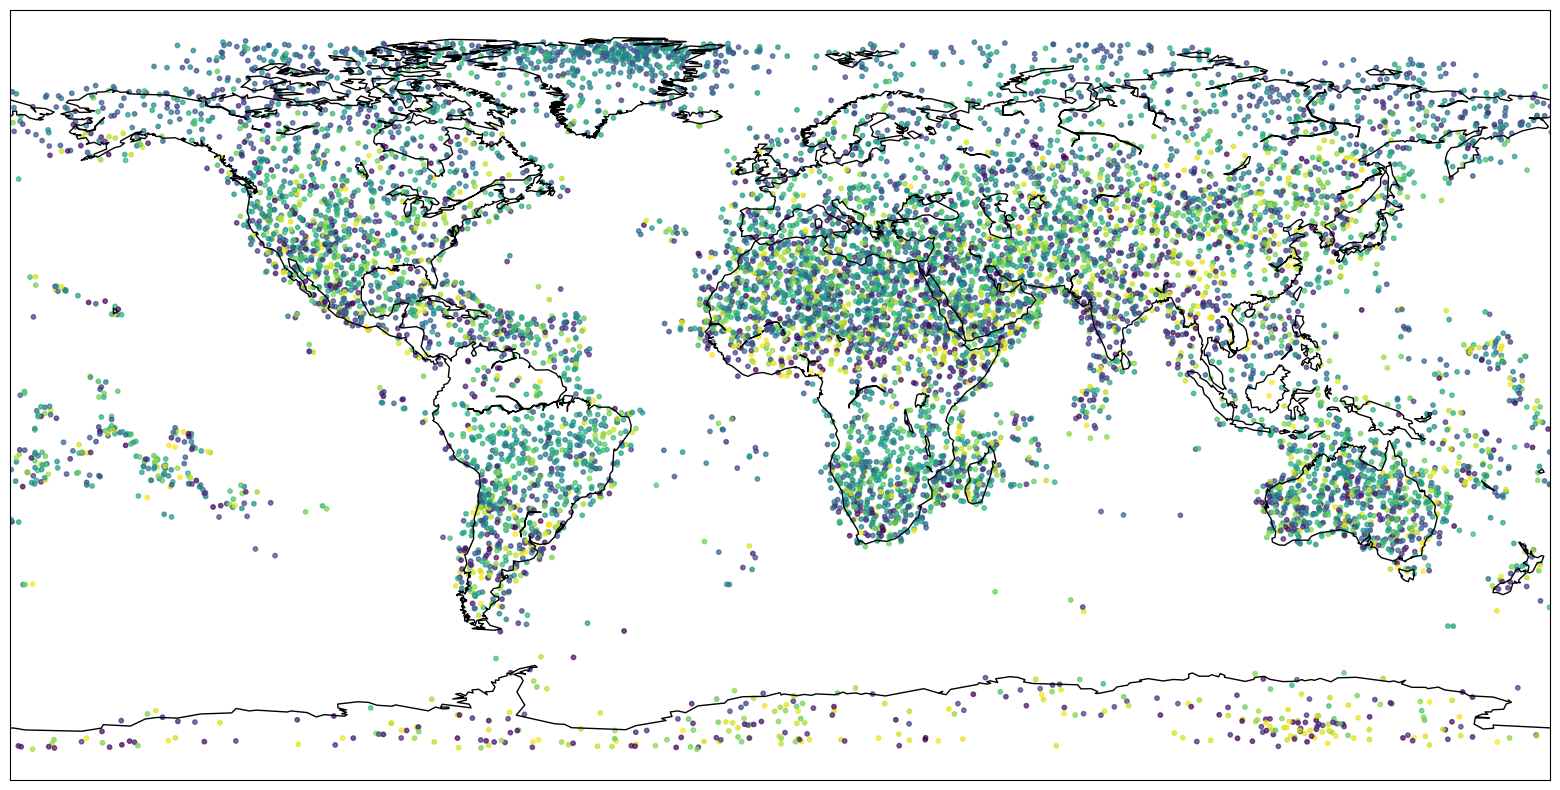

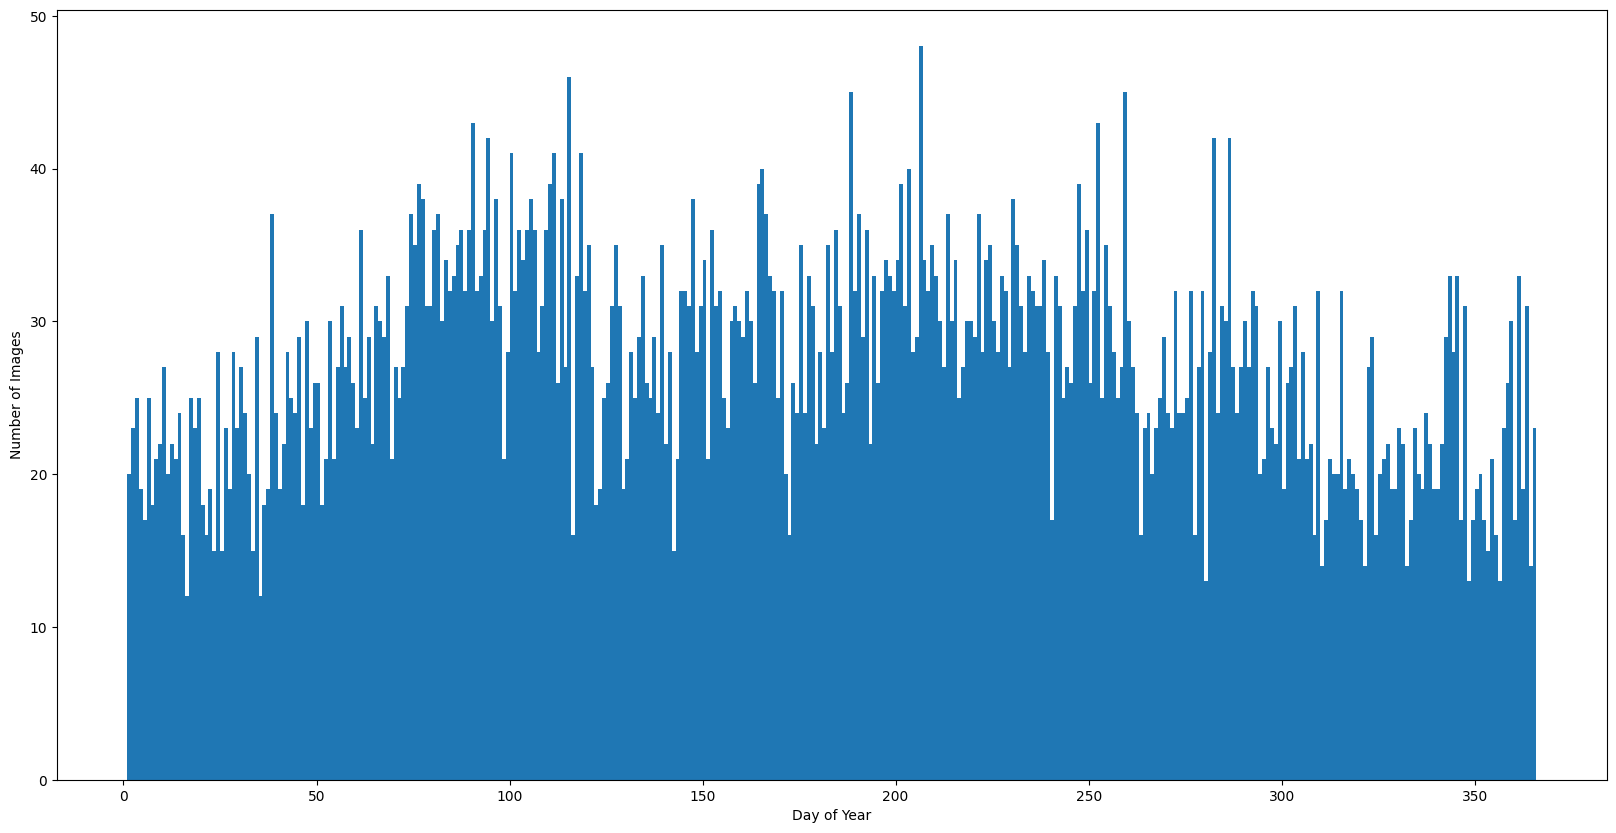

In [12]:
# Visualize the entire dataset

import glob
import datetime
img_root = "/home/leca5365/Datasets/satclip-s2-temporal/images/"

img_paths = glob.glob(f"{img_root}/*.tif")

fig, ax = plt.subplots(1,1, figsize=(20, 10))

m = Basemap(projection='cyl', resolution='c', ax=ax)
m.drawcoastlines()

doys = []
xs = []
ys = []

for img_path in img_paths:
    id, x, y, t, tags = get_metadata(img_path)
    dt = datetime.datetime.strptime(t, '%Y-%m-%dT%H:%M:%S.%f+00:00')
    doy = dt.timetuple().tm_yday
    doys.append(doy)
    xs.append(x)
    ys.append(y)

ax.scatter(xs, ys, s=10, c=doys, cmap='viridis', alpha=0.7) 
# fig.colorbar(fig.gca(), label='Day of Year', ax=ax)
# plt.show()

fig, ax = plt.subplots(1,1, figsize=(20, 10))
ax.hist(doys, bins=365)
ax.set_xlabel('Day of Year')
ax.set_ylabel('Number of Images')
plt.show()

In [4]:
import pandas as pd
import os
from tqdm import tqdm

# Iterate through dataset to check for corrupted files
CHECK_MIN_FILESIZE = 1000  # in bytes
n_skipped_files = 0

# root = "/mnt/rolf-datastore/home/leca5365/Datasets/satclip-s2-100k"
root = "/mnt/rolf-datastore/home/leca5365/Datasets/satclip"

index_fn = "index.csv"

df = pd.read_csv(os.path.join(root, index_fn))
filenames = []
points = []

n_skipped_files = 0
n_corrupted_files = 0
for i in tqdm(range(df.shape[0])):
    filename = os.path.join(root, "images", df.iloc[i]["fn"])
    
    # Useful for training subsets
    if os.path.exists(filename) == False:
        n_skipped_files += 1
        continue

    if os.path.getsize(filename) < CHECK_MIN_FILESIZE:
        n_skipped_files += 1
        continue
    
    # Ensure it is valid raster
    try:
        
        with rasterio.open(filename) as f:
            data = f.read().astype(np.float32)
    except:
        n_skipped_files += 1
        n_corrupted_files += 1
        print(f"Corrupted file: {filename}")
        continue

    filenames.append(filename)
    points.append(
        (df.iloc[i]["lon"], df.iloc[i]["lat"])
    )

print(f"Number of skipped files: {n_skipped_files}")

 10%|▉         | 9638/100000 [03:23<02:06, 711.82it/s]

Corrupted file: /mnt/rolf-datastore/home/leca5365/Datasets/satclip/images/patch_9384.tif
Corrupted file: /mnt/rolf-datastore/home/leca5365/Datasets/satclip/images/patch_9385.tif
Corrupted file: /mnt/rolf-datastore/home/leca5365/Datasets/satclip/images/patch_9386.tif


 24%|██▎       | 23739/100000 [08:18<25:44, 49.39it/s] 

Corrupted file: /mnt/rolf-datastore/home/leca5365/Datasets/satclip/images/patch_23728.tif


 39%|███▉      | 39196/100000 [13:45<21:16, 47.64it/s]

Corrupted file: /mnt/rolf-datastore/home/leca5365/Datasets/satclip/images/patch_39187.tif


 94%|█████████▍| 94160/100000 [33:00<00:06, 945.06it/s]

Corrupted file: /mnt/rolf-datastore/home/leca5365/Datasets/satclip/images/patch_93836.tif
Corrupted file: /mnt/rolf-datastore/home/leca5365/Datasets/satclip/images/patch_93837.tif
Corrupted file: /mnt/rolf-datastore/home/leca5365/Datasets/satclip/images/patch_93838.tif
Corrupted file: /mnt/rolf-datastore/home/leca5365/Datasets/satclip/images/patch_93839.tif
Corrupted file: /mnt/rolf-datastore/home/leca5365/Datasets/satclip/images/patch_93841.tif
Corrupted file: /mnt/rolf-datastore/home/leca5365/Datasets/satclip/images/patch_93842.tif
Corrupted file: /mnt/rolf-datastore/home/leca5365/Datasets/satclip/images/patch_93843.tif
Corrupted file: /mnt/rolf-datastore/home/leca5365/Datasets/satclip/images/patch_93844.tif
Corrupted file: /mnt/rolf-datastore/home/leca5365/Datasets/satclip/images/patch_93845.tif
Corrupted file: /mnt/rolf-datastore/home/leca5365/Datasets/satclip/images/patch_93846.tif
Corrupted file: /mnt/rolf-datastore/home/leca5365/Datasets/satclip/images/patch_93847.tif
Corrupted 

100%|██████████| 100000/100000 [33:19<00:00, 50.02it/s] 

Number of skipped files: 5870
